<a href="https://colab.research.google.com/github/pandu1992/PIB-Grant/blob/main/EV_Dynamic_Pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install stable-baselines3 gymnasium torch numpy pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 2.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.env_checker import check_env


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
class EVDemandGenerator:
    def __init__(self, seed=42):
        np.random.seed(seed)

    def generate(self, t, price):
        """
        Synthetic but realistic EV charging demand model.
        """
        # Daily seasonality
        hour = t % 24
        daily = 10 + 8 * np.sin(2 * np.pi * hour / 24)

        # Weekly seasonality
        weekly = 5 if (t // 24) % 7 < 5 else -3  # weekday vs weekend

        # Price elasticity
        elasticity = -1.5
        price_effect = elasticity * price

        noise = np.random.normal(0, 2)

        demand = max(0, daily + weekly + price_effect + noise)
        return demand


In [4]:
class DemandForecaster:
    def __init__(self, horizon=4, noise_std=0.0):
        self.horizon = horizon
        self.noise_std = noise_std

    def forecast(self, current_demand):
        forecast = np.array(
            [current_demand + np.random.normal(0, self.noise_std)
             for _ in range(self.horizon)]
        )
        return np.clip(forecast, 0, None)


In [13]:
class EVChargingPricingEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, forecast_noise=0.0):
        super().__init__()

        self.max_steps = 24 * 30
        self.step_count = 0

        self.price_min = 0.1
        self.price_max = 1.0
        self.capacity = 30

        self.demand_model = EVDemandGenerator()
        self.forecaster = DemandForecaster(noise_std=forecast_noise)

        self.action_space = spaces.Box(
            low=np.array([self.price_min]),
            high=np.array([self.price_max]),
            dtype=np.float32
        )

        self.observation_space = spaces.Box(
            low=0,
            high=100,
            shape=(6,),
            dtype=np.float32
        )

        self.reset()

    def reset(self, seed=None, options=None):
        self.step_count = 0
        self.prev_demand = 10
        self.prev_price = 0.5
        self.time = 0

        forecast = self.forecaster.forecast(self.prev_demand)

        obs = np.concatenate([
            [self.prev_demand, self.prev_price],
            forecast
        ]).astype(np.float32)

        return obs, {}

    def step(self, action):
        price = float(action[0])
        demand = self.demand_model.generate(self.time, price)

        revenue = price * demand
        congestion_penalty = max(0, demand - self.capacity) * 2
        reward = revenue - congestion_penalty

        forecast = self.forecaster.forecast(demand)

        obs = np.concatenate([
            [demand, price],
            forecast
        ]).astype(np.float32)

        self.prev_demand = demand
        self.prev_price = price
        self.time += 1
        self.step_count += 1

        terminated = self.step_count >= self.max_steps

        info = {
            "demand": demand,
            "price": price,
            "revenue": revenue
        }

        return obs, reward, terminated, False, info

In [14]:
env = EVChargingPricingEnv(forecast_noise=1.0)
check_env(env)

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/env_checker.py:507: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


In [15]:
env = DummyVecEnv([lambda: EVChargingPricingEnv(forecast_noise=1.0)])

model = PPO(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    gamma=0.99,
    verbose=1
)

model.learn(total_timesteps=200_000)


/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1605 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| time/                   |             |
|    fps                  | 1133        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.007956433 |
|    clip_fraction        | 0.115       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | -0.00328    |
|    learning_rate        | 0.0003      |
|    loss                 | 1.82e+03    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0115     |
|    std                  | 0.997       |
|    value_loss           | 4.44e+03    |
-----------------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1045        |
|    iterations           | 3           |
|    time_elapsed         | 5     

In [19]:
class ReactiveEVEnv(EVChargingPricingEnv):
    def __init__(self, forecast_noise=0.0):
        super().__init__(forecast_noise=forecast_noise)
        self.observation_space = spaces.Box(
            low=0,
            high=100,
            shape=(2,),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        obs, _ = super().reset()
        return obs[:2], {}

    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)
        return obs[:2], reward, terminated, truncated, info

In [20]:
reactive_env = DummyVecEnv([lambda: ReactiveEVEnv()])
reactive_model = PPO("MlpPolicy", reactive_env, verbose=1)
reactive_model.learn(total_timesteps=200_000)

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1676 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1185        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010646416 |
|    clip_fraction        | 0.16        |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.41       |
|    explained_variance   | 0.00306     |
|    learning_rate        | 0.0003      |
|    loss                 | 1.81e+03    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0172     |
|    std                  | 0.989       |
|    value_loss           | 5e+03       |
-----------------

In [27]:
def evaluate(model, env, steps=1000):
    obs, _ = env.reset()
    prices, actual_demands, rewards, forecasted_demands = [], [], [], []

    for _ in range(steps):
        # The forecast for the demand that will be observed in this step's info dictionary
        # obs[2] contains the immediate forecast used for the current decision
        if len(obs) > 2: # Only append if the observation space includes forecast (not for reactive_env)
            forecasted_demands.append(obs[2])

        action, _ = model.predict(obs)
        obs, reward, done, _, info = env.step(action)

        prices.append(info["price"])
        actual_demands.append(info["demand"])
        rewards.append(reward)

        if done:
            break

    return prices, actual_demands, rewards, forecasted_demands

In [28]:
test_env = EVChargingPricingEnv(forecast_noise=1.0)
prices_f, demands_f, rewards_f, forecasted_demands_f = evaluate(model, test_env)

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


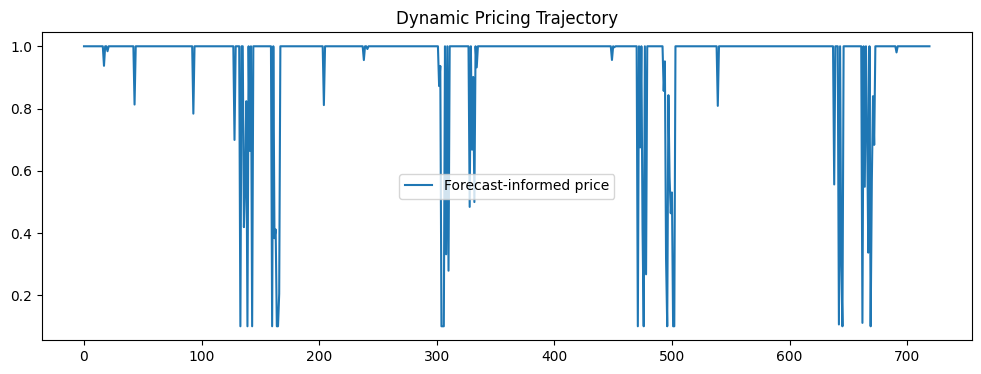

In [23]:
plt.figure(figsize=(12,4))
plt.plot(prices_f, label="Forecast-informed price")
plt.title("Dynamic Pricing Trajectory")
plt.legend()
plt.show()


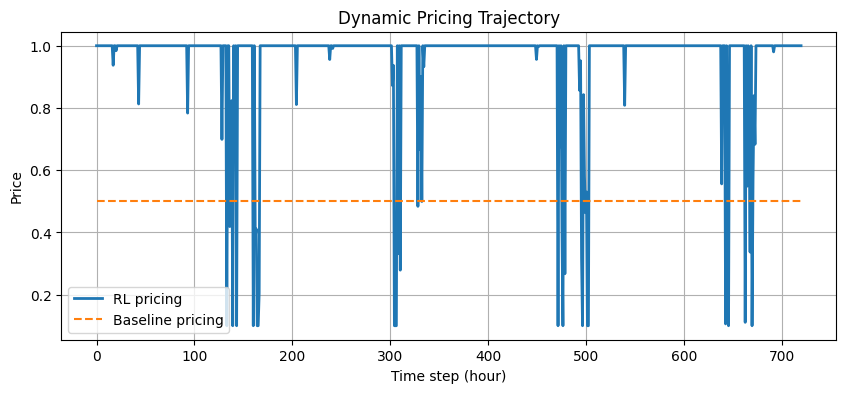

In [25]:
plt.figure(figsize=(10,4))
# Define baseline_prices (e.g., a constant price)
baseline_prices = np.full_like(prices_f, 0.5)

plt.plot(prices_f, label="RL pricing", linewidth=2)
plt.plot(baseline_prices, label="Baseline pricing", linestyle="--")
plt.xlabel("Time step (hour)")
plt.ylabel("Price")
plt.title("Dynamic Pricing Trajectory")
plt.legend()
plt.grid(True)
plt.show()

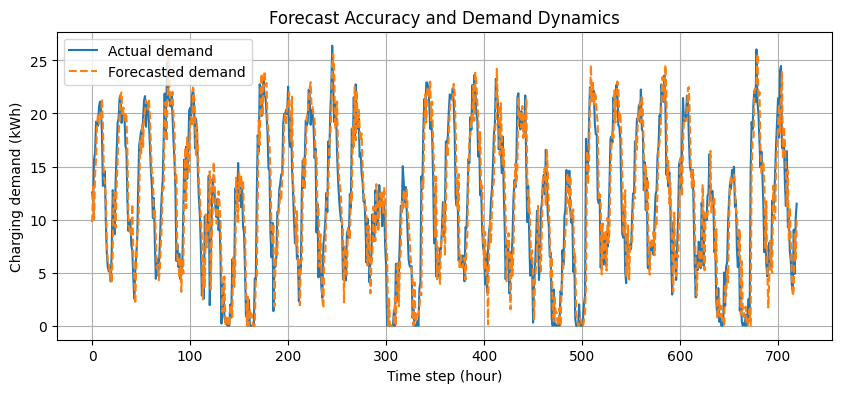

In [29]:
plt.figure(figsize=(10,4))
plt.plot(demands_f, label="Actual demand")
plt.plot(forecasted_demands_f, label="Forecasted demand", linestyle="--")
plt.xlabel("Time step (hour)")
plt.ylabel("Charging demand (kWh)")
plt.title("Forecast Accuracy and Demand Dynamics")
plt.legend()
plt.grid(True)
plt.show()

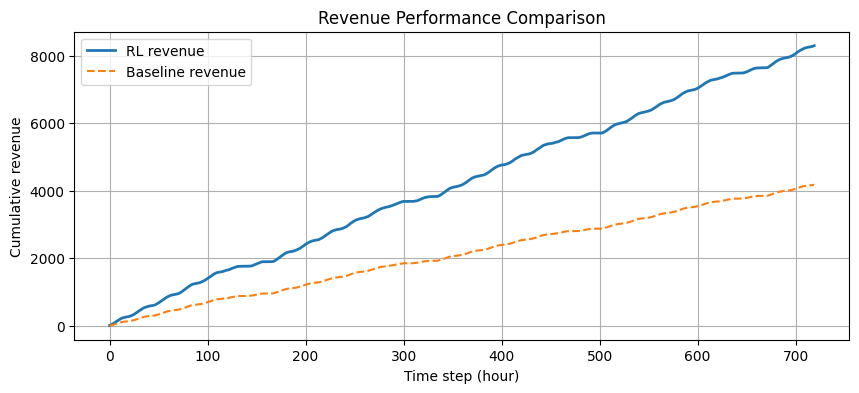

In [32]:
cumulative_revenue_rl = np.cumsum(np.array(prices_f) * np.array(demands_f))
cumulative_revenue_baseline = np.cumsum(baseline_prices * np.array(demands_f))

plt.figure(figsize=(10,4))
plt.plot(cumulative_revenue_rl, label="RL revenue", linewidth=2)
plt.plot(cumulative_revenue_baseline, label="Baseline revenue", linestyle="--")
plt.xlabel("Time step (hour)")
plt.ylabel("Cumulative revenue")
plt.title("Revenue Performance Comparison")
plt.legend()
plt.grid(True)
plt.show()

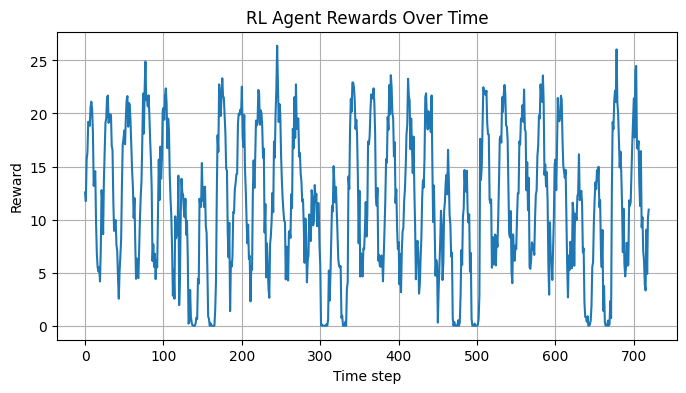

In [34]:
plt.figure(figsize=(8,4))
plt.plot(rewards_f)
plt.xlabel("Time step")
plt.ylabel("Reward")
plt.title("RL Agent Rewards Over Time")
plt.grid(True)
plt.show()

In [35]:
import numpy as np

def price_volatility(prices):
    """Standard deviation of price changes"""
    return np.std(np.diff(prices))

def demand_served(demand):
    """Total energy served"""
    return np.sum(demand)


In [43]:
def run_experiment(seed, mode="forecast", forecast_noise=0.0, capacity=30):
    """
    mode:
        'forecast'   -> pricing uses demand forecast
        'noforecast' -> reactive pricing (last observed demand only)
        'baseline'   -> static pricing
    """
    import numpy as np

    np.random.seed(seed)

    T = 720  # 30 days hourly
    base_price = 0.5

    # Demand generator
    hours = np.arange(T)
    true_demand = (
        10
        + 7 * np.sin(2 * np.pi * hours / 24)
        + np.random.normal(0, 2, T)
    )
    true_demand = np.clip(true_demand, 0, capacity)

    # Forecast (imperfect, noisy)
    forecast = true_demand + np.random.normal(0, forecast_noise, T)

    prices = []
    rewards = []

    for t in range(T):

        if mode == "baseline":
            price = base_price

        elif mode == "noforecast":
            # Reactive policy: only past information
            if t == 0:
                last_demand = true_demand[t]
            else:
                last_demand = true_demand[t - 1]

            price = min(1.0, 0.6 + 0.02 * last_demand)

        elif mode == "forecast":
            # Anticipatory policy
            price = min(1.0, 0.6 + 0.02 * forecast[t])

        else:
            raise ValueError("Unknown pricing mode")

        served = min(true_demand[t], capacity)
        reward = price * served

        prices.append(price)
        rewards.append(reward)

    prices = np.array(prices)
    rewards = np.array(rewards)

    return {
        "revenue": rewards.sum(),
        "volatility": price_volatility(prices),
        "demand_served": demand_served(true_demand)
    }


In [48]:
seeds = [0, 1, 2, 3, 4]

modes = ["forecast", "noforecast", "baseline"]
results = {m: [] for m in modes}

for seed in seeds:
    for mode in modes:
        results[mode].append(run_experiment(seed, mode))

summary = []

for mode in modes:
    revenue = [r["revenue"] for r in results[mode]]
    volatility = [r["volatility"] for r in results[mode]]
    demand = [r["demand_served"] for r in results[mode]]

    summary.append({
        "Policy": mode,
        "Revenue (mean)": np.mean(revenue),
        "Revenue (std)": np.std(revenue),
        "Volatility (mean)": np.mean(volatility),
        "Volatility (std)": np.std(volatility),
        "Demand served (mean)": np.mean(demand)
    })

df_summary = pd.DataFrame(summary)
df_summary

,Policy,Revenue (mean),Revenue (std),Volatility (mean),Volatility (std),Demand served (mean)
0,forecast,6187.578469,76.951397,0.061822,0.000835,7214.894377
1,noforecast,6119.461041,78.272165,0.061802,0.000847,7214.894377
2,baseline,3607.447189,37.290130,0.000000,0.000000,7214.894377


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


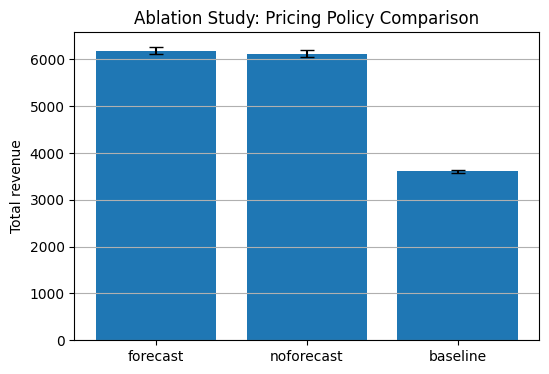

In [45]:
import matplotlib.pyplot as plt

labels = [row["Policy"] for row in summary]
means = [row["Revenue (mean)"] for row in summary]
stds = [row["Revenue (std)"] for row in summary]

plt.figure(figsize=(6,4))
plt.bar(labels, means, yerr=stds, capsize=5)
plt.ylabel("Total revenue")
plt.title("Ablation Study: Pricing Policy Comparison")
plt.grid(axis="y")
plt.show()


In [46]:
noise_levels = [0.0, 1.0, 2.0, 4.0]
sensitivity_results = []

for noise in noise_levels:
    revenues = []
    for seed in seeds:
        res = run_experiment(seed, mode="forecast", forecast_noise=noise)
        revenues.append(res["revenue"])
    sensitivity_results.append({
        "Forecast noise": noise,
        "Revenue mean": np.mean(revenues),
        "Revenue std": np.std(revenues)
    })

df_sensitivity = pd.DataFrame(sensitivity_results)
df_sensitivity


,Forecast noise,Revenue mean,Revenue std
0,0.0,6187.578469,76.951397
1,1.0,6184.943596,78.363067
2,2.0,6177.288805,80.238398
3,4.0,6148.505904,84.083791


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


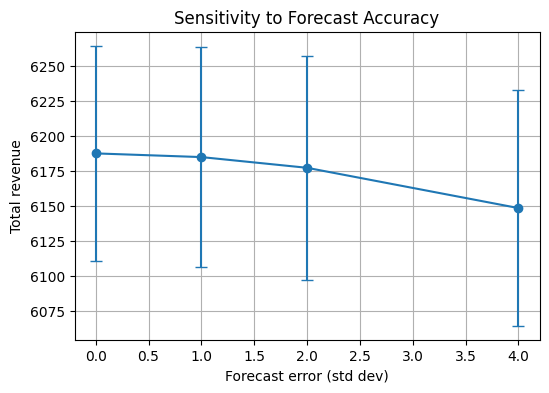

In [47]:
plt.figure(figsize=(6,4))
plt.errorbar(
    df_sensitivity["Forecast noise"],
    df_sensitivity["Revenue mean"],
    yerr=df_sensitivity["Revenue std"],
    marker="o",
    capsize=4
)
plt.xlabel("Forecast error (std dev)")
plt.ylabel("Total revenue")
plt.title("Sensitivity to Forecast Accuracy")
plt.grid(True)
plt.show()
